# Analisis Dataset Project 1: US Accidents (March 2023)

Dataset ini merupakan dataset berskala besar yang berisi laporan kecelakaan lalu lintas di US. Karena ukuran file yang sangat besar (~3GB), analisis ini menggunakan *subset* dari dataset untuk keperluan eksplorasi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Membaca sebagian data (100,000 baris pertama) karena ukuran file 3GB
df = pd.read_csv('../datasets/project1/US_Accidents_March23.csv', nrows=100000)
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


## 1. Analisis Missing Value

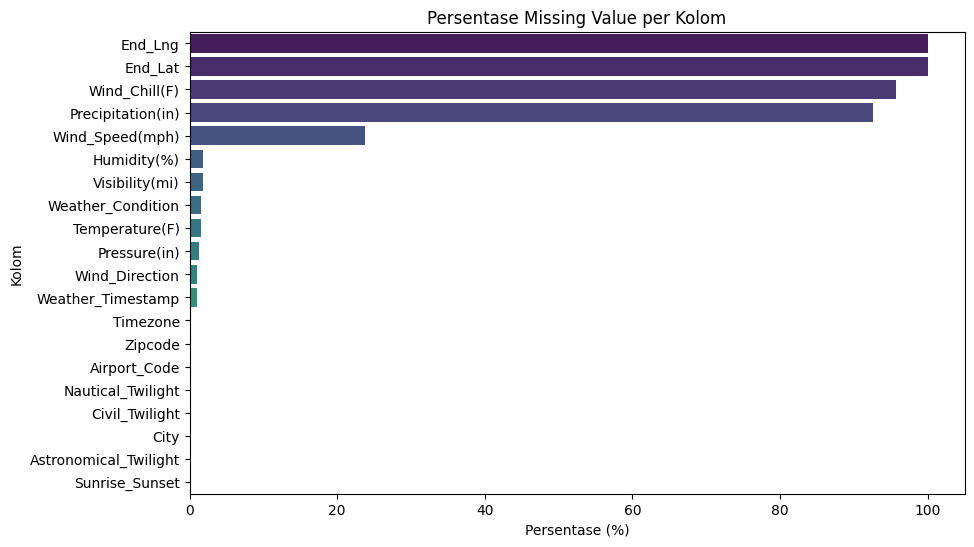

Top 5 Missing Values:
 End_Lng              100.000
End_Lat              100.000
Wind_Chill(F)         95.678
Precipitation(in)     92.632
Wind_Speed(mph)       23.820
dtype: float64


In [2]:
# Menghitung persentase missing value per kolom
missing_percentages = df.isna().sum().sort_values(ascending=False) / len(df) * 100
missing_percentages = missing_percentages[missing_percentages > 0]

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_percentages.values, y=missing_percentages.index, palette='viridis')
plt.title('Persentase Missing Value per Kolom')
plt.xlabel('Persentase (%)')
plt.ylabel('Kolom')
plt.show()

print("Top 5 Missing Values:\n", missing_percentages.head())

### Penanganan Missing Value:
- Kolom dengan missing value > 50% (misal `End_Lat`, `End_Lng` jika ada, dll) -> **Dihapus (Drop)**
- Numerik (misal `Temperature(F)`, `Humidity(%)`) -> Imputasi dengan **Median**
- Kategorikal (misal `Weather_Condition`, `Wind_Direction`) -> Imputasi dengan **Modus (Mode)** atau kategori 'Unknown'

## 2. Analisis Outliers

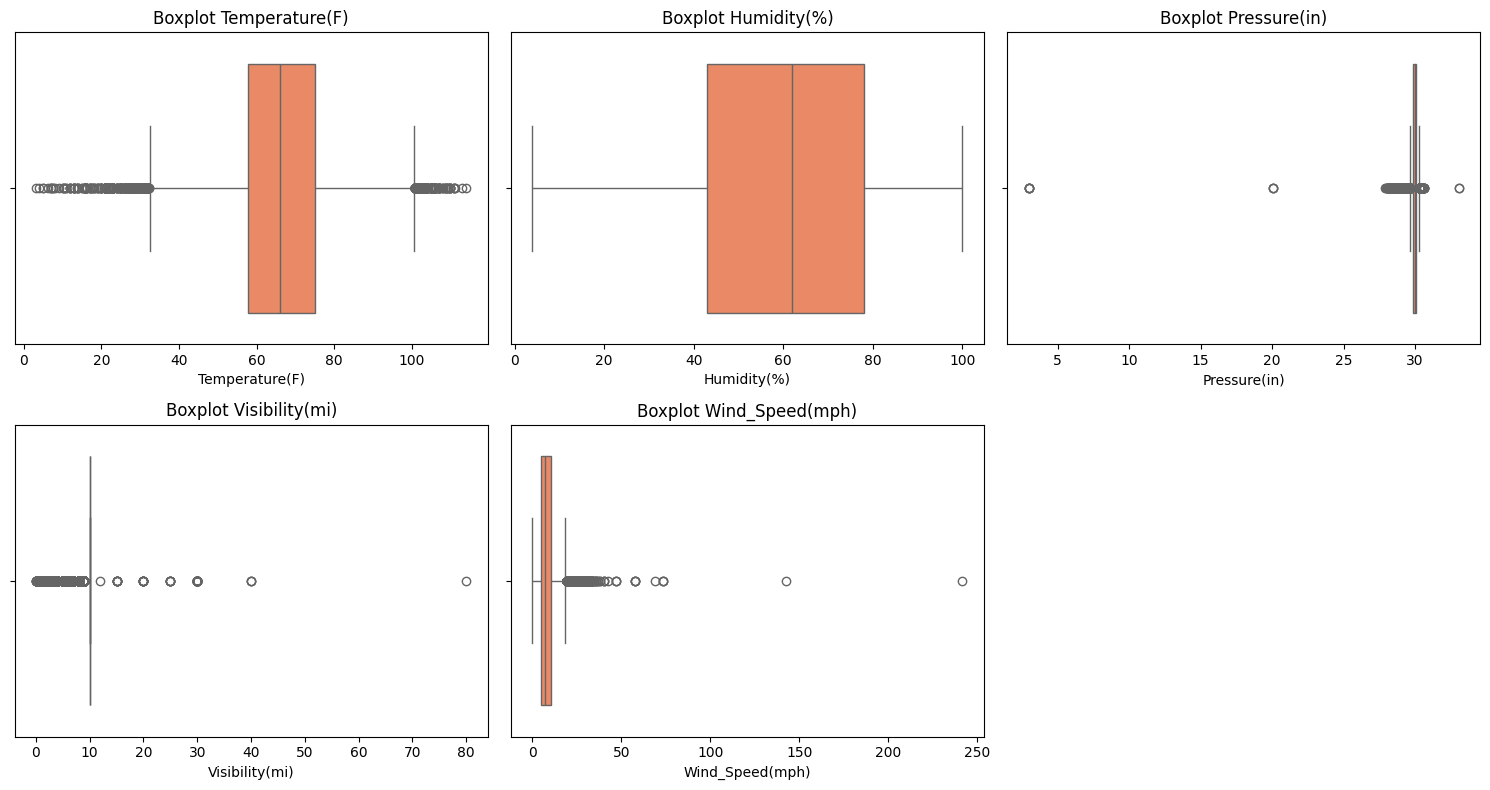

In [3]:
# Visualisasi Outlier menggunakan Boxplot pada beberapa fitur numerik
features_to_check = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)']

plt.figure(figsize=(15, 8))
for i, feature in enumerate(features_to_check):
    if feature in df.columns:
        plt.subplot(2, 3, i+1)
        sns.boxplot(x=df[feature], color='coral')
        plt.title(f'Boxplot {feature}')
plt.tight_layout()
plt.show()

### Proses Penanganan Outliers:
1. **Metode IQR (Interquartile Range)**: Menghitung batas bawah (Q1 - 1.5*IQR) dan batas atas (Q3 + 1.5*IQR). Nilai di luar rentang ini dapat dihapus jika jumlahnya sedikit.
2. **Capping / Winsorization**: Mengganti nilai ekstrem dengan nilai persentil ke-1 dan ke-99 agar tidak merusak distribusi data.

## 3. Transformasi dan Encoding

In [4]:
# Ekstraksi Waktu dari Start_Time
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['Hour'] = df['Start_Time'].dt.hour
df['DayOfWeek'] = df['Start_Time'].dt.dayofweek
df['Month'] = df['Start_Time'].dt.month

# Encoding variabel Boolean (True/False)
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

# Encoding variabel kategorikal dengan Label/Target Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Contoh pada Weather_Condition dan Sunrise_Sunset
for col in ['Weather_Condition', 'Sunrise_Sunset', 'City']:
    if col in df.columns:
        df[col] = df[col].astype(str)
        df[col+'_Encoded'] = le.fit_transform(df[col])

print("Hasil Encoding:")
df[['Weather_Condition', 'Weather_Condition_Encoded', 'Sunrise_Sunset', 'Sunrise_Sunset_Encoded']].head()

Hasil Encoding:


,Weather_Condition,Weather_Condition_Encoded,Sunrise_Sunset,Sunrise_Sunset_Encoded
0,Light Rain,17,Night,1
1,Light Rain,17,Night,1
2,Overcast,27,Night,1
3,Mostly Cloudy,25,Night,1
4,Mostly Cloudy,25,Day,0


## 4. Rekomendasi Model Prediksi

Tujuan utama dataset ini biasanya adalah **memprediksi `Severity` (Tingkat Keparahan Kecelakaan)** yang bernilai 1 hingga 4. Ini adalah masalah **Klasifikasi Multikelas (Multiclass Classification)**.

Rekomendasi model terbaik:
1. **XGBoost Classifier / LightGBM**: Sangat optimal untuk dataset berskala besar, mampu menangani missing value secara otomatis, dan memberikan akurasi sangat tinggi dengan waktu training efisien.
2. **Random Forest Classifier**: Model ansambel berbasis pohon keputusan yang robust terhadap outlier dan tidak memerlukan scaling.
3. **Deep Learning (Neural Networks - Tabular Data)**: Dapat digunakan dengan arsitektur Feed Forward Neural Network jika data sudah distandarisasi sepenuhnya.